![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np

---
## 1. Load the raw data

The Global Impacts Dataset of Invasive Alien Species (GIDIAS) has first been published on the 21. of Mai 2025 by Springer Natur and authored by S. Bacher et al.  (https://doi.org/10.6084/m9.figshare.27908838)

In [2]:
df_raw = pd.read_csv("../data/raw/GIDIAS_20250417_machine_read.csv")

---
## 2. First look

The first step is to take a closer look at the raw data to assess the overall shape of the dataset, examine the types of data it contains, and identify any further relevant information or patterns that may require closer investigation.

In [ ]:
df_raw.shape

(22865, 90)

The dataset contains 22865 rows and 90 columns.

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 22865 entries, 0 to 22864
Data columns (total 90 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   rowID                               22865 non-null  int64  
 1   UniqueID                            22865 non-null  str    
 2   IAS.Species.Name                    22865 non-null  str    
 3   Verified.Name.GBIF.Taxon            22346 non-null  str    
 4   GBIF.scientificName.with.author     21574 non-null  str    
 5   Genus                               22308 non-null  str    
 6   Family                              22281 non-null  str    
 7   Order                               22201 non-null  str    
 8   Class                               20943 non-null  str    
 9   Phylum                              22310 non-null  str    
 10  Kingdom                             22339 non-null  str    
 11  IAS.Taxon                           22865 non-null  

A first look at the data shows that some columns contain null values. The data type of each column will be assessed in more detail later.

In [5]:
df_raw.head()

,rowID,UniqueID,IAS.Species.Name,Verified.Name.GBIF.Taxon,GBIF.scientificName.with.author,Genus,Family,Order,Class,Phylum,...,NCP.Medicinal,NCP.Learning,NCP.Physical,NCP.Identities,NCP.Options,CWB.Safety,CWB.Assets,CWB.Health,CWB.Relations,CWB.Freedom
0,1,AF_Fish_crayfish_00001,Gambusia affinis,Gambusia affinis,"Gambusia affinis (Baird & Girard, 1853)",Gambusia,Poeciliidae,Cyprinodontiformes,NaN,Chordata,...,False,False,False,False,False,False,False,False,False,False
1,2,AF_Fish_crayfish_00002,Onchorhynchus mykiss,Oncorhynchus mykiss,"Oncorhynchus mykiss (Walbaum, 1792)",Oncorhynchus,Salmonidae,Salmoniformes,NaN,Chordata,...,False,False,False,False,False,False,False,False,False,False
2,3,AF_Fish_crayfish_00003,Procambrus clarkii,Procambarus clarkii,"Procambarus clarkii (Girard, 1852)",Procambarus,Cambaridae,Decapoda,Malacostraca,Arthropoda,...,False,False,False,False,False,False,False,False,False,False
3,4,AF_Fish_crayfish_00004,Procambrus clarkii,Procambarus clarkii,"Procambarus clarkii (Girard, 1852)",Procambarus,Cambaridae,Decapoda,Malacostraca,Arthropoda,...,False,False,False,False,False,False,False,False,False,False
4,5,AF_Fish_crayfish_00005,Ctenopharyngodon idella,Ctenopharyngodon idella,"Ctenopharyngodon idella (Valenciennes, 1844)",Ctenopharyngodon,Cyprinidae,Cypriniformes,NaN,Chordata,...,False,False,False,False,False,False,False,False,False,False


In [6]:
df_raw.tail()

,rowID,UniqueID,IAS.Species.Name,Verified.Name.GBIF.Taxon,GBIF.scientificName.with.author,Genus,Family,Order,Class,Phylum,...,NCP.Medicinal,NCP.Learning,NCP.Physical,NCP.Identities,NCP.Options,CWB.Safety,CWB.Assets,CWB.Health,CWB.Relations,CWB.Freedom
22860,22861,ants_0840,Solenopsis invicta,Solenopsis invicta,"Solenopsis invicta Buren, 1972",Solenopsis,Formicidae,Hymenoptera,Insecta,Arthropoda,...,False,False,False,False,False,False,False,False,False,False
22861,22862,ants_0841,Solenopsis invicta,Solenopsis invicta,"Solenopsis invicta Buren, 1972",Solenopsis,Formicidae,Hymenoptera,Insecta,Arthropoda,...,False,False,False,False,False,False,False,False,False,False
22862,22863,ants_0842,Wasmannia auropunctata,Wasmannia auropunctata,"Wasmannia auropunctata (Roger, 1863)",Wasmannia,Formicidae,Hymenoptera,Insecta,Arthropoda,...,False,False,False,False,False,False,False,True,False,False
22863,22864,ants_0843,Wasmannia auropunctata,Wasmannia auropunctata,"Wasmannia auropunctata (Roger, 1863)",Wasmannia,Formicidae,Hymenoptera,Insecta,Arthropoda,...,False,False,False,False,False,False,True,False,False,False
22864,22865,ants_0844,Wasmannia auropunctata,Wasmannia auropunctata,"Wasmannia auropunctata (Roger, 1863)",Wasmannia,Formicidae,Hymenoptera,Insecta,Arthropoda,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# comparing the number of unique ID with the number of rows
df_raw["UniqueID"].nunique()==len(df_raw)

True

The first and last five rows of the dataset show us that each row could be uniquely identified by the species ID. This was verified by comparing the number of rowas of the dataset with the number of unique IDs.

In [ ]:
# cheking the data types
df_raw.dtypes

rowID                              int64
UniqueID                             str
IAS.Species.Name                     str
Verified.Name.GBIF.Taxon             str
GBIF.scientificName.with.author      str
                                   ...  
CWB.Safety                          bool
CWB.Assets                          bool
CWB.Health                          bool
CWB.Relations                       bool
CWB.Freedom                         bool
Length: 90, dtype: object

In [ ]:
col_types = df_raw.dtypes.reset_index()
col_types.columns = ["row", "type"]
col_types["type"].value_counts()

type
str        44
bool       42
float64     3
int64       1
Name: count, dtype: int64

44 columns are of type string, 42 are of type boolean, three are floats, and only one is an integer.

In [38]:
# checking for duplicates
df_raw.duplicated().sum()

np.int64(0)

The dataset does not contain duplicate rows.

#### Summary: 2 - First look at the data 
The dataset contains 22,865 rows and 90 columns. Of these, 44 columns are of type string, 42 are of type boolean, three are floats, and only one is an integer. No rows are duplicates.

The large number of boolean columns raises the question of whether all of them are necessary. To answer this question, the metadata will be examined more closely in Part 3.

Each row in the dataset represents one species. Each species can be identified by its unique ID (`UniqueID`). Other columns, such as the species name, may also uniquely identify a row.

---
## 3. Taking a look at the metadata

The metadata needs to be investigated, to see if all columns are relevant to the research questions.

In [ ]:
df_meta = pd.read_excel("../data/raw/GIDIAS_metadata_20250507.xlsx")

In [ ]:
df_meta.head()

,Column,Variable,Format,Number or range of unique entries,Explanation,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
0,A,rowID,Numeric,22865,Numeric ID of impact record,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B,UniqueID,Text,Free text,"Unique identifier of impact records, indicatin...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,C,IAS.Species.Name,Text,3779,Name of invasive alien species (IAS) as assign...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,D,Verified.Name.GBIF.Taxon,Text,3354,"Species name of IAS, or higher taxonomic level...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E,GBIF.scientificName.with.author,Text,3205,Species name with author and year of descripti...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_meta.columns

Index(['Column', 'Variable', 'Format', 'Number or range of unique entries',
       'Explanation', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12',
       'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16',
       'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20',
       'Unnamed: 21', 'Unnamed: 22'],
      dtype='str')

In [ ]:
# filtering for columns with values of type boolean in order to read the explanation and decide if the variable is essential for the analysis
df_bool = df_raw.select_dtypes(include= "bool").columns.to_list()
df_meta[df_meta["Variable"].isin(df_bool)] 

,Column,Variable,Format,Number or range of unique entries,Explanation,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
21,V,Peer.reviewed,Logical,2,Whether or not the source was peer-reviewed,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,AB,Island.k,Logical,2,Whether the location was on an island,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,AD,Protected.area.k,Logical,2,Whether the location was in a protected area,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,AO,global.extinction,Logical,2,Whether the impact led to a global extinction ...,True,False,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
52,BA,UoA.Dry,Logical,2,Unit of Analysis: dummy variable indicating if...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,BB,UoA.Boreal,Logical,2,Unit of Analysis: dummy variable indicating if...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,BC,UoA.Mediterranean,Logical,2,Unit of Analysis: dummy variable indicating if...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,BD,UoA.Tundra,Logical,2,Unit of Analysis: dummy variable indicating if...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,BE,UoA.Savanna,Logical,2,Unit of Analysis: dummy variable indicating if...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,BF,UoA.Grassland,Logical,2,Unit of Analysis: dummy variable indicating if...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# Creating a list with the names of the columns with interesting values
bool_columns = ["Island.k", "Protected.area.k", "global.extinction"]

### Summary 3 - Taking a look at the metadata
Afer reviewing the metadata the columns, that could be interesting for the analysis are the following: 
- `Island.k`
- `Protected.area.k`
- `global.extinction`

---
## 4. Data quality
The quality of the data will be asseset in the next part. 

In [ ]:
df_raw.isna().sum() 

rowID                                 0
UniqueID                              0
IAS.Species.Name                      0
Verified.Name.GBIF.Taxon            519
GBIF.scientificName.with.author    1291
                                   ... 
CWB.Safety                            0
CWB.Assets                            0
CWB.Health                            0
CWB.Relations                         0
CWB.Freedom                           0
Length: 90, dtype: int64

Some columns appear to contain null values. It is important to identify which columns contain these values in order to determine how they should be handled during the data-cleaning process.

In [ ]:
df_raw.isna().sum()[df_raw.isna().sum() > 0]

Verified.Name.GBIF.Taxon                519
GBIF.scientificName.with.author        1291
Genus                                   557
Family                                  584
Order                                   664
Class                                  1922
Phylum                                  555
Kingdom                                 526
IAS.Functional.Group                   3178
native.range.of.IAS                   17412
Text.excerpt                           4147
DOI                                   16507
Year                                    672
Year.of.impact                        19911
Type.of.source                         1718
Language                                764
Methodology.details                    2781
Region                                  131
Country.Location                       1249
Island                                14863
Protected.area                        19632
Realm                                    73
Units.of.Analysis.clean         

Rows with missing values in the columns "year" and "region" can be discarded, as these are essential vaules for to answer the reserch question.

In [32]:
df_raw["Year"].dtypes

dtype('float64')

Years are of type float and should be of type date.

### Summary 4. Data quality 
An important part of the data processing will be to standardise the column names and ensure a consistent naming convention.
Null values can be kept in the dataset. Removing a null value would implicate removing the entire row. Depending on the research question and the column the null value is in, it should be decided if the value and therefore the row can be kept or not. For the rows that have missing values in the columns `Year` and `Region` can be discarded as these will impact answering the research question.
The type of the dates should be changed from float to data.


---
## 5. Categorical and numerical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

### 5.1 Categorical values

In [21]:
for column in df_raw:
    print (df_raw[column].unique())

[    1     2     3 ... 22863 22864 22865]
<ArrowStringArray>
['AF_Fish_crayfish_00001', 'AF_Fish_crayfish_00002', 'AF_Fish_crayfish_00003',
 'AF_Fish_crayfish_00004', 'AF_Fish_crayfish_00005', 'AF_Fish_crayfish_00006',
 'AF_Fish_crayfish_00007', 'AF_Fish_crayfish_00008', 'AF_Fish_crayfish_00009',
 'AF_Fish_crayfish_00010',
 ...
              'ants_0835',              'ants_0836',              'ants_0837',
              'ants_0838',              'ants_0839',              'ants_0840',
              'ants_0841',              'ants_0842',              'ants_0843',
              'ants_0844']
Length: 22865, dtype: str
<ArrowStringArray>
[            'Gambusia affinis',         'Onchorhynchus mykiss',
           'Procambrus clarkii',      'Ctenopharyngodon idella',
           'Apiosoma piscicola',   'Schyzocotyle acheilognathi',
            'Lernea cyprinacea', 'Ichthyophthirius multifiliis',
       'Chilodonella piscicola',      'Chilodonella hexasticha',
 ...
               'Nylanderia sp.'

In [ ]:
free_text_columns = []
for column in df_raw:
    meta_row = df_meta.loc[df_meta["Variable"] == column] # finding right row the metadata for each column form the raw data   
    if meta_row["Number or range of unique entries"].iloc[0] == "Free text": # filtering the column for wich the number or range of unique entries is free text
        free_text_columns.append(column) # add the name of the column to the list of columns with free text
print(free_text_columns)

['UniqueID', 'IAS.Functional.Group', 'native.range.of.IAS', 'Text.excerpt', 'Methodology.details', 'Affected.native.species.Details', 'Affected.ecosystem.property', 'investigated.level.of.organization', 'details.NCP', 'magnitude.NCP', 'details.CWB', 'magnitude.CWB.details', 'IPLC']


We now have a list of column names, that can be filtered out. The problem is that the column `UniqueID` is marked as free text, though this column is very important to keep.

In [28]:
free_text_columns.remove("UniqueID")

In [39]:
# checking the number of columns with free text
len(free_text_columns)

12

In [44]:
# looking at the distribution of categorical varibles
for column in df_raw.columns:
    print(column, df_raw[column].nunique())

rowID 22865
UniqueID 22865
IAS.Species.Name 3779
Verified.Name.GBIF.Taxon 3353
GBIF.scientificName.with.author 3204
Genus 2079
Family 761
Order 242
Class 84
Phylum 36
Kingdom 8
IAS.Taxon 4
IAS.Functional.Group 312
native.range.of.IAS 393
Reference 6783
Text.excerpt 9445
DOI 1848
Assessor 106
Year 87
Year.of.impact 92
Type.of.source 15
Peer.reviewed 2
Language 16
Methodology.details 1082
Region 5
Country.Location 414
Island 368
Island.k 2
Protected.area 413
Protected.area.k 2
Realm 3
Units.of.Analysis.clean 88
Spatial.scale 5
Affected.native.species.Details 7736
Affected.native.species.Taxon 5
Affected.ecosystem.property 1557
investigated.level.of.organization 158
mechanism.Nature.clean 39
direction.Nature 3
direct.or.indirect.Nature 3
global.extinction 2
magnitude.Nature 4
affected.NCP.clean 50
details.NCP 1070
direction.NCP 3
magnitude.NCP 671
affected.CWB.clean 15
details.CWB 773
direction.CWB 3
magnitude.CWB 5
magnitude.CWB.details 101
IPLC 45
UoA.Dry 2
UoA.Boreal 2
UoA.Mediterranea

Some columns such as `Region` and `Kingdom` only have a few distinct values.

In [ ]:
# cheking if the values of the columns Region and Kingdom are consistent
df_raw["Kingdom"].unique()

<ArrowStringArray>
[      'Animalia',      'Chromista',        'Plantae',          'Fungi',
        'Viruses',       'Bacteria',              nan, 'incertae sedis',
       'Protozoa']
Length: 9, dtype: str

In [58]:
df_raw["Region"].unique()

<ArrowStringArray>
[                 'Africa',            'Asia-Pacific',
                       nan,                'Americas',
              'Antarctica', 'Europe_and_Central_Asia']
Length: 6, dtype: str

The values of the column `Kindgom` and `Region` are consitent.

### 5.2 Numerical values

In [ ]:
# filtering for columns with values of type float in the metadata
df_float = df_raw.select_dtypes(include= "float").columns.to_list()
df_meta[df_meta["Variable"].isin(df_float)] 

,Column,Variable,Format,Number or range of unique entries,Explanation,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22
18,S,Year,Numeric,1882-2022,Year of the publication describing the impact,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,T,Year.of.impact,Numeric,1600-2019,"Year of impact, if different from the publicat...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,AP,magnitude.Nature,Numeric,0-3,EICAT impact magnitudes: level to which a nati...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# comparing metadata with the value types of the raw data
df_raw.select_dtypes(include="float")

,Year,Year.of.impact,magnitude.Nature
0,2015.0,2012.0,1.0
1,2015.0,NaN,2.0
2,2002.0,NaN,2.0
3,2001.0,NaN,2.0
4,2016.0,NaN,2.0
...,...,...,...
22860,2000.0,NaN,NaN
22861,2008.0,NaN,NaN
22862,2014.0,NaN,NaN
22863,2014.0,NaN,NaN


The value type for numerical variables in the dataset correspnd to the information contained in the metadata. However the `magnitude.Nature` is of type float and could be of type integer or, depending on the analysis of type string.
It would make more sense for the years to be of type integer as well.

In [50]:
df_raw["magnitude.CWB"].dtypes

<StringDtype(na_value=nan)>

In [68]:
df_raw["magnitude.Nature"].dtypes

dtype('float64')

In [65]:
df_raw["magnitude.CWB"].unique()

<ArrowStringArray>
[nan, '1', '3', '2', 'positive', '0']
Length: 6, dtype: str

The magintude columns, should be of the same type, either numeric or string. Depending on the analysis a different type could give different options. Magnitude should be converted into a string type to preserve the "positive" variable.

In [51]:
# inspecting the values of the `Year` column
print(df_raw["Year"].min())
print(df_raw["Year"].max())

1882.0
2022.0


<Axes: >

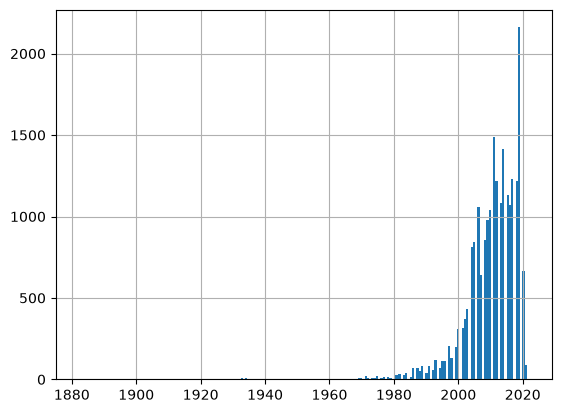

In [53]:
df_raw["Year"].hist(bins=200)

The column  `Year` has a wide range of values from 1882 to 2022. Most entries are made between the years 2000 and 2020. This inside is interesting to answer the first research question.

In [62]:
print(df_raw["Year.of.impact"].min())
print(df_raw["Year.of.impact"].max())

1600.0
2019.0


<Axes: >

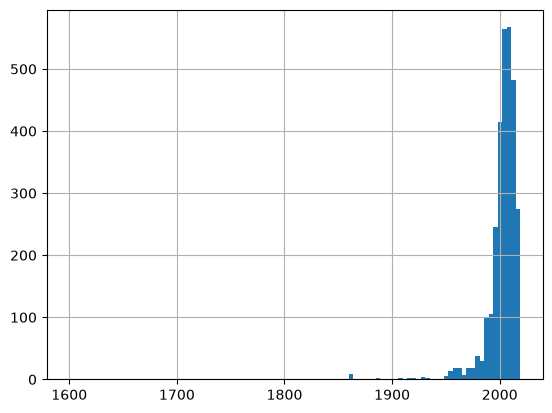

In [64]:
df_raw["Year.of.impact"].hist(bins=100)

The Year of publication does not necessarily correpond to the year the impact.

### Summary 5 - Categorical and numerical columns

The only numerical column is the unique species id. Columns with boolean data type could be transformed into 0 and 1 value and used to create count value for groups.
All other columns are cotegorical columns. 12 columns contain free text, which will be discarded during the data cleaning. 
Columns with few distinct values such as Region and Kingdom are interessting to create the SQL tables.

The data type of the numerical variables should be adjusted depending on the respective column. The `magnitude.Nature` and `magnitude.CWS` columns should have the same data type.

In the `Year` column, the years between 2000 and 2020 are the most prevalent. However, the full range of years is still relevant and may provide valuable information for the analysis.

The Year of publication does not necessarily correpond to the year of the impact. Therefore we could create a new column `Year_probability` unsing the year of publication except fo the species that have a earlier data of impact.

---
## 6. Research questions

1. When where invasive species introduces the most? Is there a time where introduction of invasive species boomed?
2. Which countries are the most impacted by invasive species?
3. Which invasive species has the greater impact?
   - number of regions the species is affecting and magnitude at wich it is affecting the region

---
## 7. Into notebook 02

**1. data quality corrections**
- standardising the column names
- correcting the data types (`Year` and `Year.of.impact` to integer and `magnitude.Nature` to string)

**2. Columns to discard**
- all columns that contain free text, except `UniqueID` because it contains an important identifier
- columns that contain boolean values and are not necessary for the analysis

**3. Discarding null values**

As the dataset mostly contains categorical values, null values cannot be replaced by means or medians. For each case, it should be assessed whether the corresponding row should be discarded from the analysis. Rows containing null values in the columns `Year` and `Region` may be excluded, as these values are essential for the analysis.

**4. Creating a new column `Year_probability`**

Creating new column with the probable year of impact. The year corredponds to the year of publication unless ther is an other value in the Year of impact column.

**5. Building the tables**

To answer the reasearch questions the following tables sould be build:

 a) Species table(main table): containing all infomation on the invasive species

 b) Region table: containing all infomation the the region the species is impacting

 c) Impact table: containing all infomation the impact the invasive species has